<a href="https://colab.research.google.com/github/26b21a4250kiet/Weather-Predictior/blob/main/Backend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       MARKOV CHAIN: WEATHER PREDICTION

Weather States:
1. Sunny
2. Cloudy
3. Rainy

Transition Matrix P:
[[0.5 0.3 0.2]
 [0.2 0.5 0.3]
 [0.3 0.2 0.5]]

Row sums of transition matrix:
[1. 1. 1.]
✓ Valid transition matrix: Every row sums to 1.

EIGENVALUE ANALYSIS

Eigenvalues:
1.000000+0.000000j
0.250000+0.086603j
0.250000-0.086603j

Eigenvalue closest to 1:
λ = 1.000000

Steady-State Distribution:
Sunny   : 0.3333 (33.33%)
Cloudy  : 0.3333 (33.33%)
Rainy   : 0.3333 (33.33%)

Verification of Steady State:
π × P = [0.33333333 0.33333333 0.33333333]
π     = [0.33333333 0.33333333 0.33333333]

WEATHER DISTRIBUTION AFTER 100 DAYS

Today's weather: Sunny
Sunny   : 0.3333 (33.33%)
Cloudy  : 0.3333 (33.33%)
Rainy   : 0.3333 (33.33%)

Difference from steady state:
Sunny   : 0.00000000
Cloudy  : 0.00000000
Rainy   : 0.00000000

✓ The distribution has approximately converged to
  the steady-state distribution.

EFFECT OF TODAY'S WEATHER

Starting weather: Sunny
Sunny   : 0.3333 (33.33%)
Cloudy 

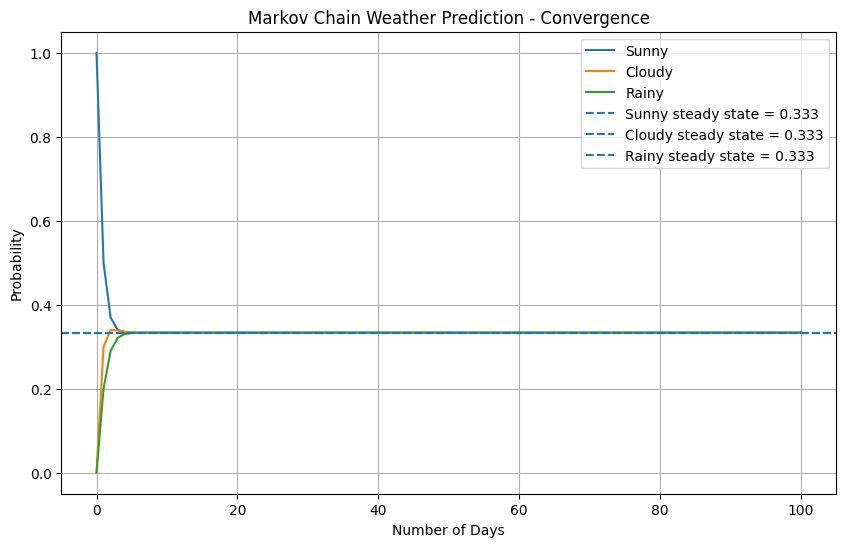


FINAL CONCLUSION

1. Weather is represented using three states:
   Sunny, Cloudy and Rainy.

2. The transition matrix represents the probability
   of moving from one weather state to another.

3. The distribution after n days is calculated using:
       X_n = X_0 × P^n

4. The steady-state distribution is obtained from the
   eigenvector corresponding to eigenvalue λ = 1.

5. As the number of days increases, the weather
   distribution converges toward the steady state.

6. The starting weather affects short-term predictions,
   but its effect decreases over time.

Therefore, after a sufficiently large number of days,
the distribution becomes approximately independent
of today's weather for this Markov chain.

PROJECT COMPLETED


In [1]:
# ================================================================
# B.TECH MATHEMATICS MINI PROJECT
# MARKOV CHAIN: WEATHER PREDICTION (B6)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. DEFINE WEATHER STATES
# ------------------------------------------------
states = ["Sunny", "Cloudy", "Rainy"]

# ------------------------------------------------
# 2. TRANSITION MATRIX
# ------------------------------------------------
# Rows    = Today's weather
# Columns = Tomorrow's weather
#
#          Sunny  Cloudy  Rainy
P = np.array([
    [0.5,   0.3,   0.2],   # Sunny
    [0.2,   0.5,   0.3],   # Cloudy
    [0.3,   0.2,   0.5]    # Rainy
])

print("=" * 65)
print("       MARKOV CHAIN: WEATHER PREDICTION")
print("=" * 65)

print("\nWeather States:")
for i, state in enumerate(states):
    print(f"{i+1}. {state}")

print("\nTransition Matrix P:")
print(P)

# Check that each row sums to 1
print("\nRow sums of transition matrix:")
print(P.sum(axis=1))

if np.allclose(P.sum(axis=1), 1):
    print("✓ Valid transition matrix: Every row sums to 1.")
else:
    print("✗ Invalid transition matrix.")

# ------------------------------------------------
# 3. EIGENVALUES AND EIGENVECTORS
# ------------------------------------------------
eigenvalues, eigenvectors = np.linalg.eig(P.T)

print("\n" + "=" * 65)
print("EIGENVALUE ANALYSIS")
print("=" * 65)

print("\nEigenvalues:")
for value in eigenvalues:
    print(f"{value:.6f}")

# Find eigenvector corresponding to eigenvalue 1
index = np.argmin(np.abs(eigenvalues - 1))
steady_state = np.real(eigenvectors[:, index])

# Normalize so probabilities add up to 1
steady_state = steady_state / steady_state.sum()

print("\nEigenvalue closest to 1:")
print(f"λ = {eigenvalues[index].real:.6f}")

print("\nSteady-State Distribution:")
for state, probability in zip(states, steady_state):
    print(f"{state:8s}: {probability:.4f} ({probability*100:.2f}%)")

# Verify steady state
print("\nVerification of Steady State:")
print("π × P =", steady_state @ P)
print("π     =", steady_state)

# ------------------------------------------------
# 4. PREDICTION AFTER 100 DAYS
# ------------------------------------------------
days = 100

# Today's weather = Sunny
initial_state = np.array([1, 0, 0])

# X_n = X_0 × P^n
P_100 = np.linalg.matrix_power(P, days)
distribution_100 = initial_state @ P_100

print("\n" + "=" * 65)
print(f"WEATHER DISTRIBUTION AFTER {days} DAYS")
print("=" * 65)

print("\nToday's weather: Sunny")

for state, probability in zip(states, distribution_100):
    print(f"{state:8s}: {probability:.4f} ({probability*100:.2f}%)")

# ------------------------------------------------
# 5. COMPARE WITH STEADY STATE
# ------------------------------------------------
difference = np.abs(distribution_100 - steady_state)

print("\nDifference from steady state:")
for state, diff in zip(states, difference):
    print(f"{state:8s}: {diff:.8f}")

if np.allclose(distribution_100, steady_state, atol=0.01):
    print("\n✓ The distribution has approximately converged to")
    print("  the steady-state distribution.")
else:
    print("\nThe distribution has not completely converged yet.")

# ------------------------------------------------
# 6. DOES TODAY'S WEATHER MATTER?
# ------------------------------------------------
print("\n" + "=" * 65)
print("EFFECT OF TODAY'S WEATHER")
print("=" * 65)

initial_conditions = {
    "Sunny":  np.array([1, 0, 0]),
    "Cloudy": np.array([0, 1, 0]),
    "Rainy":  np.array([0, 0, 1])
}

for today, initial in initial_conditions.items():

    result = initial @ P_100

    print(f"\nStarting weather: {today}")

    for state, probability in zip(states, result):
        print(f"{state:8s}: {probability:.4f} ({probability*100:.2f}%)")

# ------------------------------------------------
# 7. CONVERGENCE CALCULATION
# ------------------------------------------------
max_days = 100

# Store probability distributions
history = []

for day in range(max_days + 1):
    distribution = initial_state @ np.linalg.matrix_power(P, day)
    history.append(distribution)

history = np.array(history)

# ------------------------------------------------
# 8. CONVERGENCE GRAPH
# ------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    range(max_days + 1),
    history[:, 0],
    label="Sunny"
)

plt.plot(
    range(max_days + 1),
    history[:, 1],
    label="Cloudy"
)

plt.plot(
    range(max_days + 1),
    history[:, 2],
    label="Rainy"
)

# Steady-state reference lines
plt.axhline(
    steady_state[0],
    linestyle="--",
    label=f"Sunny steady state = {steady_state[0]:.3f}"
)

plt.axhline(
    steady_state[1],
    linestyle="--",
    label=f"Cloudy steady state = {steady_state[1]:.3f}"
)

plt.axhline(
    steady_state[2],
    linestyle="--",
    label=f"Rainy steady state = {steady_state[2]:.3f}"
)

plt.xlabel("Number of Days")
plt.ylabel("Probability")
plt.title("Markov Chain Weather Prediction - Convergence")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------
# 9. FINAL CONCLUSION
# ------------------------------------------------
print("\n" + "=" * 65)
print("FINAL CONCLUSION")
print("=" * 65)

print("""
1. Weather is represented using three states:
   Sunny, Cloudy and Rainy.

2. The transition matrix represents the probability
   of moving from one weather state to another.

3. The distribution after n days is calculated using:
       X_n = X_0 × P^n

4. The steady-state distribution is obtained from the
   eigenvector corresponding to eigenvalue λ = 1.

5. As the number of days increases, the weather
   distribution converges toward the steady state.

6. The starting weather affects short-term predictions,
   but its effect decreases over time.

Therefore, after a sufficiently large number of days,
the distribution becomes approximately independent
of today's weather for this Markov chain.
""")

print("=" * 65)
print("PROJECT COMPLETED")
print("=" * 65)